In [1]:
!pip -q install nltk scikit-learn pandas matplotlib seaborn joblib

import nltk

for resource in ["movie_reviews", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource)

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [2]:
import re
import string
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import movie_reviews, stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [3]:
documents = []
labels = []

for category in movie_reviews.categories():
    for file_id in movie_reviews.fileids(category):
        review = movie_reviews.raw(file_id)

        documents.append(review)
        labels.append(1 if category == "pos" else 0)

df = pd.DataFrame({
    "review": documents,
    "label": labels
})

print("Dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()

Dataset shape: (2000, 2)
label
0    1000
1    1000
Name: count, dtype: int64


,review,label
0,"plot : two teen couples go to a church party ,...",0
1,the happy bastard's quick movie review \ndamn ...,0
2,it is movies like these that make a jaded movi...,0
3,""" quest for camelot "" is warner bros . ' firs...",0
4,synopsis : a mentally unstable man undergoing ...,0


In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_review(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove punctuation and numbers
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

In [5]:
df["clean_review"] = df["review"].apply(clean_review)

df[["review", "clean_review", "label"]].head()

,review,clean_review,label
0,"plot : two teen couples go to a church party ,...",plot two teen couple church party drink drive ...,0
1,the happy bastard's quick movie review \ndamn ...,happy bastard quick movie review damn bug got ...,0
2,it is movies like these that make a jaded movi...,movie like make jaded movie viewer thankful in...,0
3,""" quest for camelot "" is warner bros . ' firs...",quest camelot warner bros first featurelength ...,0
4,synopsis : a mentally unstable man undergoing ...,synopsis mentally unstable man undergoing psyc...,0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1600
Testing samples: 400


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = []
trained_models = {}
predictions = {}

for name, classifier in models.items():

    pipeline = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                max_features=20000,
                min_df=2
            )
        ),
        ("model", classifier)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="binary",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = pipeline
    predictions[name] = y_pred

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8300,0.817308,0.850,0.833333
1,Multinomial Naive Bayes,0.8175,0.806763,0.835,0.820639
2,Linear SVM,0.8450,0.822430,0.880,0.850242


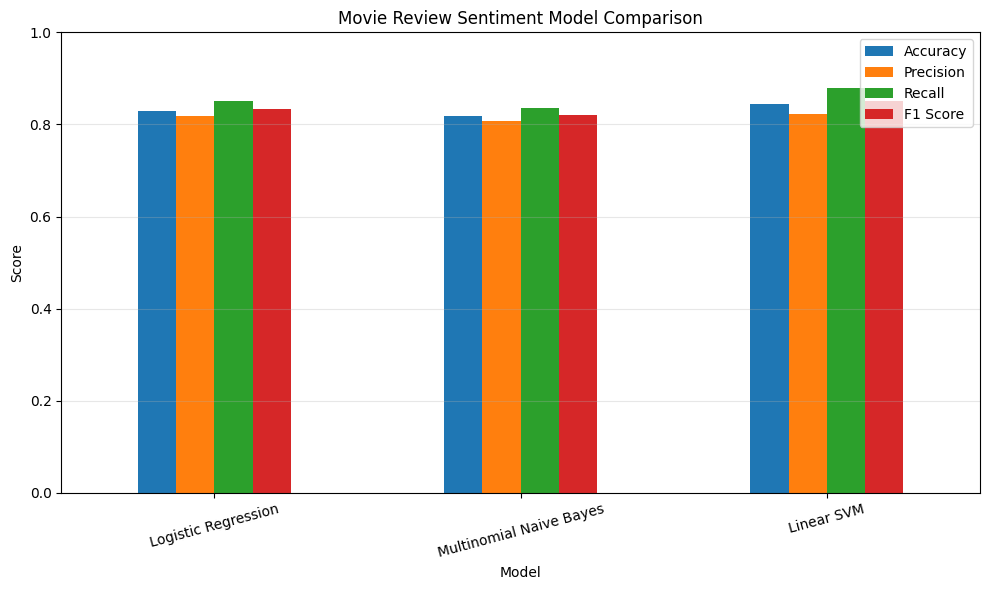

In [9]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Movie Review Sentiment Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
best_row = results_df.loc[results_df["F1 Score"].idxmax()]
best_model_name = best_row["Model"]

best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best model:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    best_predictions,
    target_names=["Negative", "Positive"]
))

Best model: Linear SVM

Classification Report:

              precision    recall  f1-score   support

    Negative       0.87      0.81      0.84       200
    Positive       0.82      0.88      0.85       200

    accuracy                           0.84       400
   macro avg       0.85      0.84      0.84       400
weighted avg       0.85      0.84      0.84       400



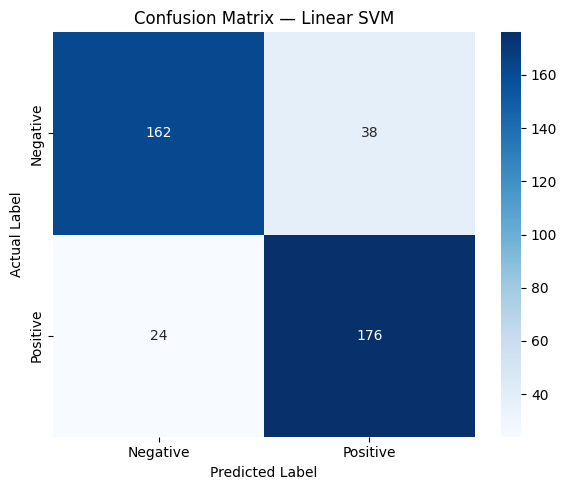

In [11]:
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

In [12]:
def predict_sentiment(review):
    cleaned_review = clean_review(review)
    prediction = best_model.predict([cleaned_review])[0]

    return "Positive 😊" if prediction == 1 else "Negative 😞"

In [13]:
sample_reviews = [
    "The movie was excellent, emotional and beautifully acted.",
    "This was a boring film with a weak story and terrible acting.",
    "I loved the direction and the performances were outstanding.",
    "The plot was confusing and the movie was a complete waste of time."
]

for review in sample_reviews:
    print("Review:", review)
    print("Prediction:", predict_sentiment(review))
    print()

Review: The movie was excellent, emotional and beautifully acted.
Prediction: Positive 😊

Review: This was a boring film with a weak story and terrible acting.
Prediction: Negative 😞

Review: I loved the direction and the performances were outstanding.
Prediction: Positive 😊

Review: The plot was confusing and the movie was a complete waste of time.
Prediction: Negative 😞



In [14]:
joblib.dump(
    best_model,
    "movie_review_sentiment_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.


In [15]:
from google.colab import files

files.download("movie_review_sentiment_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>